In [ ]:
# ==== Install required libs ====

!pip install category_encoders
!pip install xgboost


# ==== Imports ====
import numpy as np
import pandas as pd
import hashlib
import joblib
import matplotlib.pyplot as plt


# sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

# ML models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics for regression evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# For explainability
import shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [ ]:
# ==== 1. Load Dataset ====
DATA_PATH = "/content/car_prices.csv"
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)

# Checking column names to confirm dataset structure.
print("\nColumn names:")
for c in df.columns:
    print(repr(c))

Raw shape: (558837, 16)

Column names:
'year'
'make'
'model'
'trim'
'body'
'transmission'
'vin'
'state'
'condition'
'odometer'
'color'
'interior'
'seller'
'mmr'
'sellingprice'
'saledate'


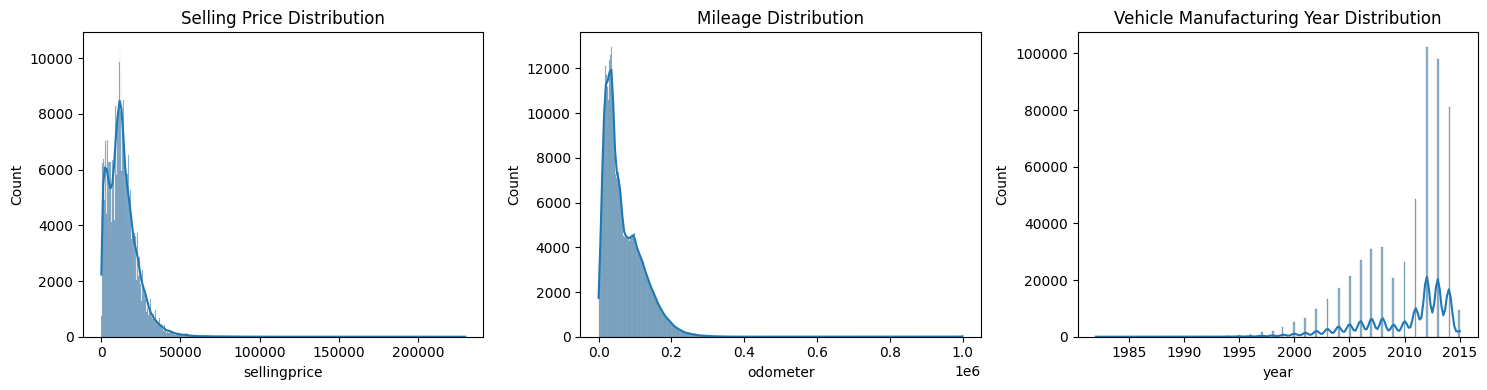

In [ ]:
# ==== EDA (just to see distributions) ====
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['sellingprice'], kde=True)
plt.title("Selling Price Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df['odometer'], kde=True)
plt.title("Mileage Distribution")

plt.subplot(1, 3, 3)
sns.histplot(df['year'], kde=True)
plt.title("Vehicle Manufacturing Year Distribution")

plt.tight_layout()
plt.show()


In [ ]:
# ==== 3. Basic Cleaning ====

# Making sure the 'saledate' column exists before processing.
col_name = "saledate"
if col_name not in df.columns:
    raise KeyError(f"Column '{col_name}' not found. Check printed column names above.")


# Converting to string first to avoid parsing issues caused by mixed types.
df[col_name] = df[col_name].astype(str).str.strip()

print("\nBefore to_datetime, dtype of saledate:", df[col_name].dtype)

# Converting sale date into proper datetime format.
# This is needed later for calculating vehicle age.
df[col_name] = pd.to_datetime(
    df[col_name],
    errors="coerce",
    infer_datetime_format=True
)

print("After to_datetime, dtype of saledate:", df[col_name].dtype)
print(df[[col_name]].head())

# Dropping rows where date could not be converted.

df = df.dropna(subset=[col_name])


Before to_datetime, dtype of saledate: object


/tmp/ipython-input-1329091532.py:14: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col_name] = pd.to_datetime(
/tmp/ipython-input-1329091532.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col_name] = pd.to_datetime(
/tmp/ipython-input-1329091532.py:14: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[col_name] = pd.to_datetime(


After to_datetime, dtype of saledate: object
                    saledate
0  2014-12-16 12:30:00+08:00
1  2014-12-16 12:30:00+08:00
2  2015-01-15 04:30:00+08:00
3  2015-01-29 04:30:00+08:00
4  2014-12-18 12:30:00+08:00


In [ ]:
# ===== 3. BASIC FILTERS =====

# Ensuring key columns have valid values.
critical_cols = ["year", "make", "model", "odometer", "sellingprice"]
df = df.dropna(subset=critical_cols)


# Removing unrealistic years and mileage values.
df = df[(df["year"] >= 1980) & (df["year"] <= 2025)]
df = df[(df["odometer"] >= 100) & (df["odometer"] <= 800_000)]

# Filtering out extremely low-priced cars (likely junk/outliers).
df = df[df["sellingprice"] >= 500]

# Dropping the very bottom 1% of prices to reduce noise.
price_q1 = df["sellingprice"].quantile(0.01)
df = df[df["sellingprice"] >= price_q1]

print("\nAfter cleaning:", df.shape)


After cleaning: (536822, 16)


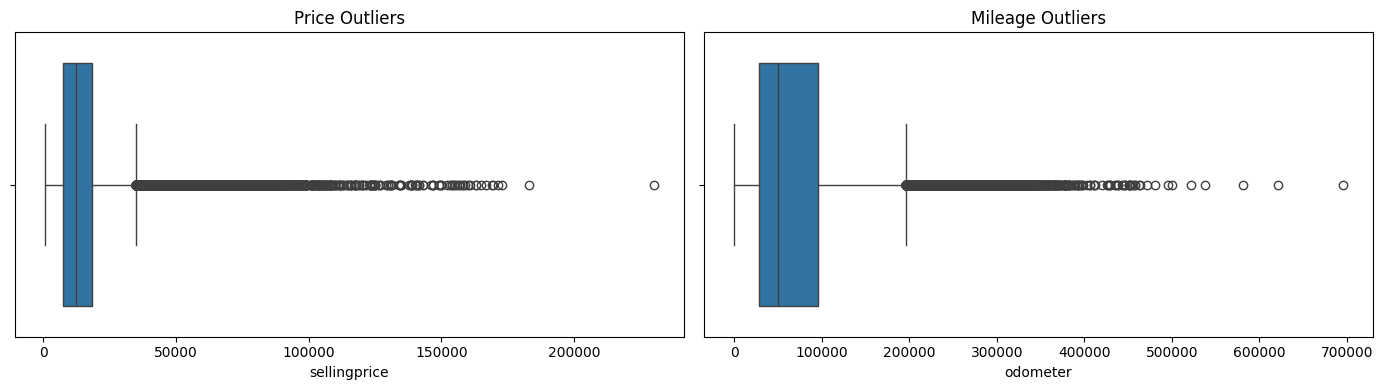

In [ ]:
# Plotting boxplots to quickly check for extreme values in price and mileage.
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["sellingprice"])
plt.title("Price Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["odometer"])
plt.title("Mileage Outliers")

plt.tight_layout()
plt.show()


In [ ]:

# ===== 4. FEATURE ENGINEERING (sale_year, vehicle_age) =====

# Reconfirming saledate as datetime (sometimes earlier operations can affect dtype).
df[col_name] = pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)
print("Right before .dt, dtype of saledate:", df[col_name].dtype)

# Extracting the sale year to calculate vehicle age.
df["sale_year"] = df[col_name].dt.year
df["vehicle_age"] = df["sale_year"] - df["year"]

# Keeping only reasonable vehicle ages.
df = df[(df["vehicle_age"] >= 0) & (df["vehicle_age"] <= 50)]

print("\nFeature engineering done. Sample:")
print(df[["year", "sale_year", "vehicle_age", col_name]].head())

Right before .dt, dtype of saledate: datetime64[ns, tzoffset('PST', 28800)]

Feature engineering done. Sample:
   year  sale_year  vehicle_age                  saledate
2  2014     2015.0          1.0 2015-01-15 04:30:00+08:00
3  2015     2015.0          0.0 2015-01-29 04:30:00+08:00
4  2014     2014.0          0.0 2014-12-18 12:30:00+08:00
6  2014     2014.0          0.0 2014-12-17 12:30:00+08:00
7  2014     2014.0          0.0 2014-12-16 13:00:00+08:00


/tmp/ipython-input-1173074688.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col_name] = pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)


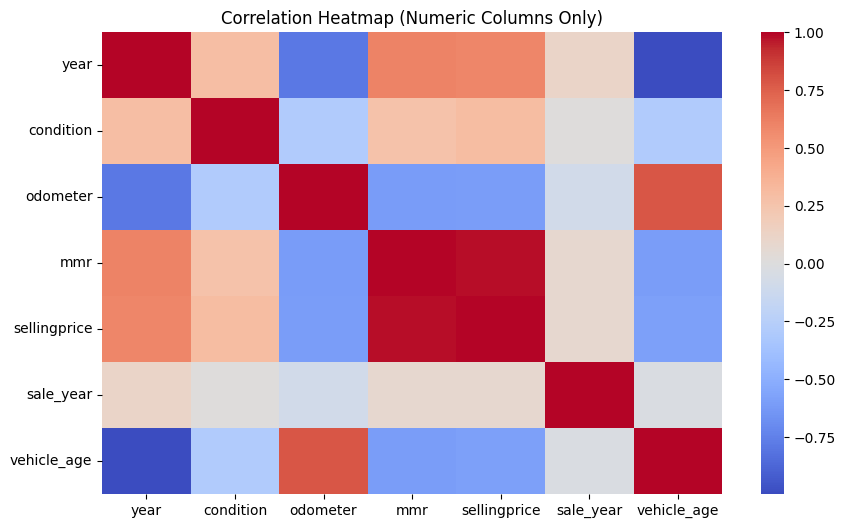

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()


In [ ]:
import hashlib

# Hashing the VIN values for privacy (only if the column exists).
# This replaces the raw VIN with a SHA-256 hash.
if "vin" in df.columns:
    def hash_vin(v):
        if pd.isna(v):
            return np.nan
        return hashlib.sha256(str(v).encode("utf-8")).hexdigest()

    df["vin_hash"] = df["vin"].apply(hash_vin)
    df = df.drop(columns=["vin"]) # removing original VIN for safety

df.head()


,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,sale_year,vehicle_age,vin_hash
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-15 04:30:00+08:00,2015.0,1.0,687db4474152e05173dc0648a161c1b178997cfe3e1194...
3,2015,Volvo,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-29 04:30:00+08:00,2015.0,0.0,f46c3b7463b7196a9391612289d4dd8d86031e7f26003d...
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 12:30:00+08:00,2014.0,0.0,59f3d2b4a722fe1899673241f53b09398f995ec81f92b8...
6,2014,BMW,M5,Base,Sedan,automatic,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,2014-12-17 12:30:00+08:00,2014.0,0.0,fc99541c7d495f2e7ca4b94c0273a468736b9b920c9002...
7,2014,Chevrolet,Cruze,1LT,Sedan,automatic,ca,2.0,28617.0,black,black,enterprise vehicle exchange / tra / rental / t...,11900.0,9800.0,2014-12-16 13:00:00+08:00,2014.0,0.0,1481c0a5047cc8e447a06e3812f973f12bd4fcbe69d3fb...


In [ ]:
# === 2. Defining Target and Feature Columns ===


TARGET = "sellingprice"

# Listing categorical columns that the model will encode.
cat_cols = [
    "make", "model", "trim", "body", "transmission",
    "color", "interior", "seller", "state"
]

# Numerical features to be scaled later.

num_cols = [
    "odometer", "mmr", "condition", "vehicle_age"
]

# Keeping only the columns that actually exist in the dataset.
cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in num_cols if c in df.columns]


# Creating feature matrix X and target vector y.
X = df[cat_cols + num_cols].copy()
y = df[TARGET].copy()

print("Categorical features:", cat_cols)
print("Numeric features:", num_cols)
print("X shape:", X.shape, "y shape:", y.shape)


Categorical features: ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior', 'seller', 'state']
Numeric features: ['odometer', 'mmr', 'condition', 'vehicle_age']
X shape: (379595, 13) y shape: (379595,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

# === 3. Train–Test Split ===
# Splitting the data for training/testing evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# === 4. Target Encoding for Categorical Columns ===
# Using TargetEncoder to avoid huge sparse matrices from one-hot encoding.

encoder = TargetEncoder(cols=cat_cols)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])


# === 5. Scaling Numerical Features ===
# Standardizing numeric values to help ML models converge better.
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()


,make,model,trim,body,transmission,color,interior,seller,state,odometer,mmr,condition,vehicle_age
271315,14536.014018,19405.509901,19591.818182,13484.082067,14365.978560,14694.270256,11166.941961,21973.606061,14230.593226,-0.998962,1.187215,1.359289,-1.022422
173622,11885.187422,4511.036671,13579.177172,15810.511726,13503.812514,8622.003651,11166.941961,8818.333940,17328.314223,1.480748,-1.048012,-0.296151,1.122495
372686,16576.093505,15615.717300,9706.758783,15810.511726,13503.812514,14694.270256,12462.006628,9948.726765,14230.593226,0.901095,-1.029070,0.155333,1.926838
124504,11059.943193,17821.859922,17027.171569,11650.841252,13503.812514,11754.158716,15489.572735,14242.844762,14230.593226,-0.069770,0.061483,0.757311,-0.486193
335799,14536.014018,18585.771608,16580.196217,15810.511726,13503.812514,15259.384101,13172.356410,22267.118535,13642.299009,-0.962906,1.695959,0.832558,-1.022422


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Simple helper function to print model performance.
def regression_metrics(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label} -> R²: {r2:.4f}, MAE: {mae:,.2f}, RMSE: {rmse:,.2f}")
    return r2, mae, rmse


In [ ]:
# === Random Forest (Baseline Model) ===
from sklearn.ensemble import RandomForestRegressor


# Using RF as a simple baseline to compare against XGBoost later.
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_r2, rf_mae, rf_rmse = regression_metrics(
    y_test, y_pred_rf, label="Random Forest"
)


Random Forest -> R²: 0.9723, MAE: 903.82, RMSE: 1,560.30


In [ ]:
# ===== SIMPLE (NON-TUNED) XGBOOST MODEL =====
# This model gives a baseline XGBoost performance before tuning.
xgb_simple = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

xgb_simple.fit(X_train, y_train)
y_pred_xgb = xgb_simple.predict(X_test)

xgb_r2, xgb_mae, xgb_rmse = regression_metrics(
    y_test, y_pred_xgb, label="Simple XGBoost"
)

print("Simple XGBoost MAE =", xgb_mae)
print("Simple XGBoost RMSE =", xgb_rmse)
print("Simple XGBoost R2 =", xgb_r2)


Simple XGBoost -> R²: 0.9672, MAE: 913.77, RMSE: 1,697.73
Simple XGBoost MAE = 913.7690881952147
Simple XGBoost RMSE = 1697.7277024045995
Simple XGBoost R2 = 0.9671772063252323


In [ ]:
# ===== Hyperparameter Tuning (RandomizedSearchCV) =====
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Base XGBoost model used for tuning.
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)


# Parameter grid for the random search.
param_distributions = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [0.0, 1.0, 2.0, 5.0],
    "reg_alpha": [0.0, 0.01, 0.05, 0.1],
}


# Running RandomizedSearchCV to find better hyperparameters.
rnd_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rnd_search.fit(X_train, y_train)

print("Best params:", rnd_search.best_params_)
print("Best CV score (neg MAE):", rnd_search.best_score_)

# Best tuned model.

best_xgb = rnd_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)

best_r2, best_mae, best_rmse = regression_metrics(
    y_test, y_pred_best, label="XGBoost (RandomizedSearchCV tuned)"
)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV score (neg MAE): -861.0964889655532
XGBoost (RandomizedSearchCV tuned) -> R²: 0.9708, MAE: 850.61, RMSE: 1,602.66


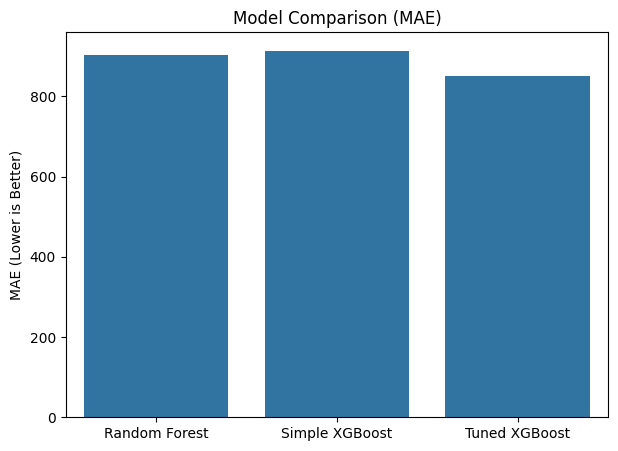

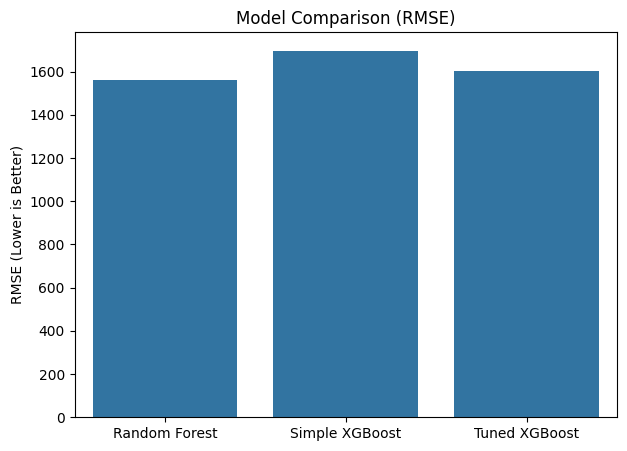

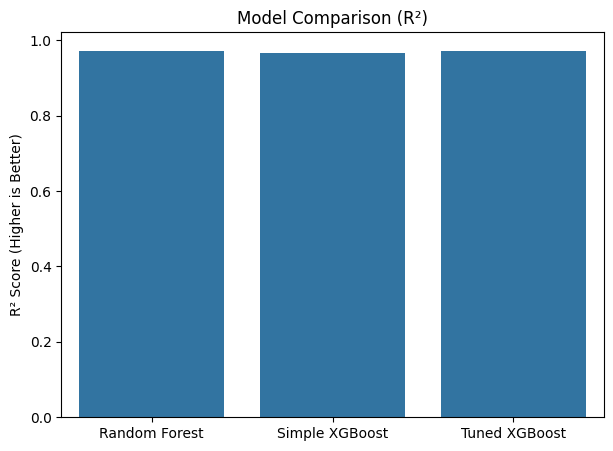

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Random Forest', 'Simple XGBoost', 'Tuned XGBoost']
mae_values = [rf_mae, xgb_mae, best_mae]
rmse_values = [rf_rmse, xgb_rmse, best_rmse]
r2_values = [rf_r2, xgb_r2, best_r2]

# MAE plot
plt.figure(figsize=(7,5))
sns.barplot(x=models, y=mae_values)
plt.title("Model Comparison (MAE)")
plt.ylabel("MAE (Lower is Better)")
plt.show()

# RMSE plot
plt.figure(figsize=(7,5))
sns.barplot(x=models, y=rmse_values)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE (Lower is Better)")
plt.show()

# R2 plot
plt.figure(figsize=(7,5))
sns.barplot(x=models, y=r2_values)
plt.title("Model Comparison (R²)")
plt.ylabel("R² Score (Higher is Better)")
plt.show()


In [ ]:
# Building a results DataFrame so we can analyse predictions and compute deal scores.

results = pd.DataFrame(index=X_test.index)
results["actual_price"] = y_test
results["pred_price"] = y_pred_best

# Adding back some original features for interpretation of results.
cols_to_join = [
    "odometer", "vehicle_age", "mmr", "condition",
    "make", "model", "trim", "body", "state", "seller"
]
cols_to_join = [c for c in cols_to_join if c in df.columns]

results = results.join(df[cols_to_join], how="left")

results.head()


,actual_price,pred_price,odometer,vehicle_age,mmr,condition,make,model,trim,body,state,seller
381727,14500.0,14540.538086,36806.0,6.0,13400.0,44.0,Nissan,Maxima,3.5 SV,Sedan,pa,carsense incorporated
136002,7000.0,8600.333984,100359.0,8.0,7875.0,37.0,Chevrolet,Silverado 2500HD,Work Truck,Regular Cab,pa,reedman toll auto world
85692,21200.0,20221.017578,33409.0,2.0,21300.0,33.0,Infiniti,G Sedan,G37 Journey,G Sedan,fl,nissan infiniti lt
389011,33300.0,33950.148438,21231.0,2.0,32600.0,46.0,Lexus,RX 350,Base,SUV,ca,california auto wholesale
97128,9400.0,9687.328125,27036.0,2.0,8925.0,47.0,Kia,Rio,LX,Sedan,ca,riverside car store inc


In [ ]:
# ==== Deal Score Components ====

# Price value: positive score means the car is listed cheaper than predicted.
price_value = (results["pred_price"] - results["actual_price"]) / results["pred_price"]
results["price_value"] = price_value.clip(-1, 1)

# Mileage score: cars with lower mileage should get higher scores.
odo = results["odometer"].astype(float)
results["mileage_score"] = 1 - (odo - odo.min()) / (odo.max() - odo.min() + 1e-9)

# Age score: newer cars should rank higher.

age = results["vehicle_age"].astype(float)
results["age_score"] = 1 - (age - age.min()) / (age.max() - age.min() + 1e-9)

# Combining weights into final Deal Score.
w_price, w_mileage, w_age = 0.6, 0.2, 0.2
results["deal_score"] = (
    w_price * results["price_value"]
    + w_mileage * results["mileage_score"]
    + w_age * results["age_score"]
)

# Checking the top 10 deals according to the deal score.
top10 = results.sort_values("deal_score", ascending=False).head(10)
top10[[
    "actual_price", "pred_price",
    "price_value", "mileage_score", "age_score", "deal_score",
    "make", "model", "trim", "body", "state", "seller"
]]


,actual_price,pred_price,price_value,mileage_score,age_score,deal_score,make,model,trim,body,state,seller
62244,1400.0,9751.948242,0.856439,0.959916,0.92,0.889847,Volkswagen,Beetle,2.5L PZEV,Hatchback,ca,gm financial
30429,1800.0,9447.455078,0.809472,0.975485,1.00,0.880780,Nissan,Sentra,FE+ S,Sedan,va,avis rac system/pv holding corp
36365,1700.0,8734.713867,0.805374,0.980890,1.00,0.879403,Chevrolet,Malibu,LTZ,Sedan,ne,hertz/tra
107742,3000.0,13174.051758,0.772280,0.967145,0.96,0.848797,Mitsubishi,Outlander Sport,ES,SUV,tx,gm financial
322486,1800.0,8608.411133,0.790902,0.947649,0.92,0.848071,Chevrolet,Impala,LT Fleet,Sedan,ca,enterprise vehicle exchange / tra / rental / t...
24479,800.0,6440.042480,0.875777,0.999862,0.60,0.845439,Honda,Odyssey,EX-L,Minivan,va,titlemax / fredericksburg va1
194087,1600.0,8758.776367,0.817326,0.910473,0.84,0.840490,Jeep,Patriot,Sport,SUV,va,wells fargo dealer services
41310,1000.0,-69.183510,1.000000,0.921429,0.28,0.840286,Volkswagen,Passat,GLX V6,Wagon,oh,coachworks
12236,850.0,4958.297363,0.828570,0.851726,0.84,0.835487,Ford,Focus,SEL,Sedan,mi,ford motor credit company llc
32482,900.0,3453.118164,0.739366,0.960313,0.96,0.827682,Ford,Fiesta,SE,Hatchback,fl,hertz/tra


In [ ]:
# == Creating a relevance label for ranking metrics ===
# A car is considered a "good deal" if it is at least 10% cheaper than predicted.
results["is_good_deal"] = (results["actual_price"] <= 0.9 * results["pred_price"]).astype(int)

y_true = results["is_good_deal"].values
y_score = results["deal_score"].values

# ==== Ranking Metrics Functions ====
def precision_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)[:k]
    return y_true[idx].sum() / k


def dcg_at_k(rels, k):
    # DCG formula (discounted cumulative gain)
    rels = np.asarray(rels, dtype=float)[:k]
    if rels.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, rels.size + 2))
    return np.sum(rels / discounts)


def ndcg_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)[:k]
    rels = y_true[idx]
    dcg = dcg_at_k(rels, k)
    ideal_rels = np.sort(y_true)[::-1][:k]
    idcg = dcg_at_k(ideal_rels, k)
    return dcg / idcg if idcg > 0 else 0.0


def average_precision(y_true, y_score):
    idx = np.argsort(-y_score)
    rels = y_true[idx]
    precisions = []
    num_rel = 0
    for i, rel in enumerate(rels, start=1):
        if rel == 1:
            num_rel += 1
            precisions.append(num_rel / i)
    if not precisions:
        return 0.0
    return np.mean(precisions)


def reciprocal_rank(y_true, y_score):
    idx = np.argsort(-y_score)
    rels = y_true[idx]
    for i, rel in enumerate(rels, start=1):
        if rel == 1:
            return 1.0 / i
    return 0.0


# Evaluating ranking performance at different cutoffs.
for k in [10, 20, 50]:
    p = precision_at_k(y_true, y_score, k)
    n = ndcg_at_k(y_true, y_score, k)
    print(f"Precision@{k}: {p:.3f}, nDCG@{k}: {n:.3f}")

map_score = average_precision(y_true, y_score)
mrr_score = reciprocal_rank(y_true, y_score)
print(f"MAP: {map_score:.3f}, MRR: {mrr_score:.3f}")


Precision@10: 0.900, nDCG@10: 0.931
Precision@20: 0.950, nDCG@20: 0.955
Precision@50: 0.980, nDCG@50: 0.976
MAP: 0.768, MRR: 1.000


Precision@K: [np.float64(1.0), np.float64(0.9), np.float64(0.95), np.float64(0.98)]
NDCG@K: [np.float64(1.0), np.float64(0.9305687780632229), np.float64(0.9551913563983283), np.float64(0.9755410594964452)]


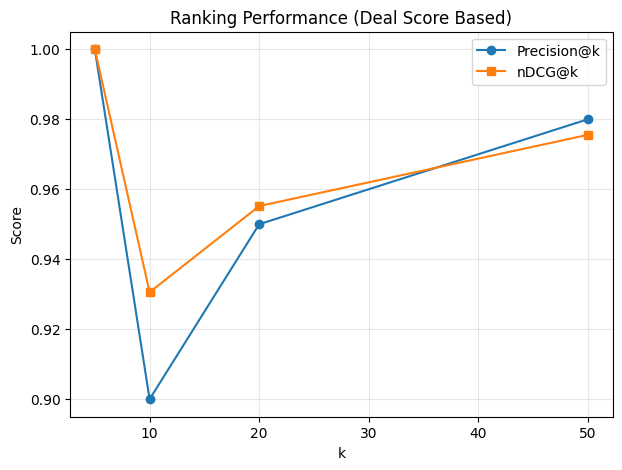

In [ ]:
# ==== Plotting ranking metrics (Precision and nDCG) ====
import numpy as np
import matplotlib.pyplot as plt

def precision_at_k(rel, k):
    return rel[:k].mean()

def dcg_at_k(rel, k):
    gains = (2**rel[:k] - 1) / np.log2(np.arange(2, k+2))
    return gains.sum()

def ndcg_at_k(rel, k):
    ideal = np.sort(rel)[::-1]
    ideal_dcg = dcg_at_k(ideal, k)
    return dcg_at_k(rel, k) / ideal_dcg if ideal_dcg > 0 else 0.0


# Sorting by Deal Score for evaluation.
results_sorted = results.sort_values("deal_score", ascending=False)
rel = results_sorted["is_good_deal"].values    # ← FIXED

ks = [5, 10, 20, 50]
precisions = [precision_at_k(rel, k) for k in ks]
ndcgs = [ndcg_at_k(rel, k) for k in ks]

print("Precision@K:", precisions)
print("NDCG@K:", ndcgs)

plt.figure(figsize=(7,5))
plt.plot(ks, precisions, marker="o", label="Precision@k")
plt.plot(ks, ndcgs, marker="s", label="nDCG@k")
plt.xlabel("k")
plt.ylabel("Score")
plt.title("Ranking Performance (Deal Score Based)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
# Simple diversity metric on top-K recommended cars (by Deal Score)
# (Just checking how many different brands appear in the top deals.)

k_div = 20
topk_for_div = results.sort_values("deal_score", ascending=False).head(k_div)

if "make" in topk_for_div.columns:
    num_unique_makes = topk_for_div["make"].nunique()
    brand_diversity = num_unique_makes / k_div
    print(f"Brand diversity in top-{k_div}: {brand_diversity:.3f} "
          f"(unique makes = {num_unique_makes} of {k_div} cars)")
else:
    print("Column 'make' not found – cannot compute brand diversity.")


Brand diversity in top-20: 0.550 (unique makes = 11 of 20 cars)


In [ ]:
# Calculating absolute prediction error for fairness and error distribution checks.
results["abs_error"] = np.abs(results["actual_price"] - results["pred_price"])

# Checking average errors grouped by state to see if performance varies regionally.
state_errors = (
    results
    .groupby("state")["abs_error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "mae"})
    .sort_values("count", ascending=False)
)

# Focusing only on states with enough data.
state_errors_filtered = state_errors[state_errors["count"] >= 1000]
state_errors_filtered.head(10)


,count,mae
state,,
ca,10965,994.952198
fl,10888,837.234433
pa,6912,815.787260
tx,6213,904.967914
ga,4673,804.912031
nj,3708,824.811264
il,3164,776.908446
tn,3136,884.402544
nc,3075,714.217995


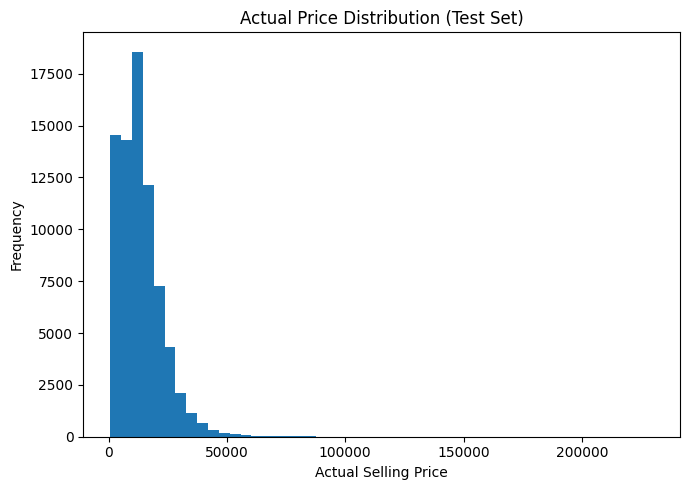

In [ ]:
# ==== Plotting several distributions to inspect model behaviour ====

plt.figure(figsize=(7, 5))
plt.hist(results["actual_price"], bins=50)
plt.xlabel("Actual Selling Price")
plt.ylabel("Frequency")
plt.title("Actual Price Distribution (Test Set)")
plt.tight_layout()
plt.show()


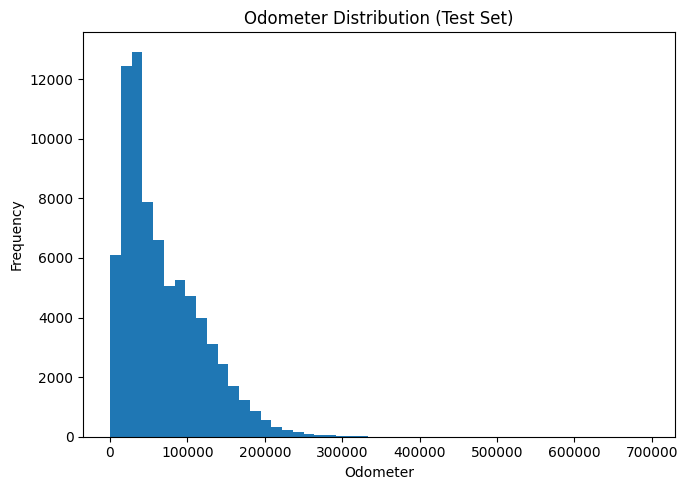

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(results["odometer"], bins=50)
plt.xlabel("Odometer")
plt.ylabel("Frequency")
plt.title("Odometer Distribution (Test Set)")
plt.tight_layout()
plt.show()


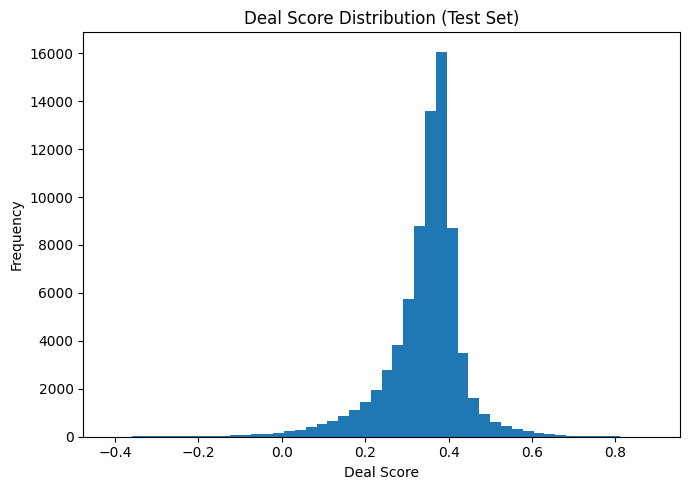

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(results["deal_score"], bins=50)
plt.xlabel("Deal Score")
plt.ylabel("Frequency")
plt.title("Deal Score Distribution (Test Set)")
plt.tight_layout()
plt.show()


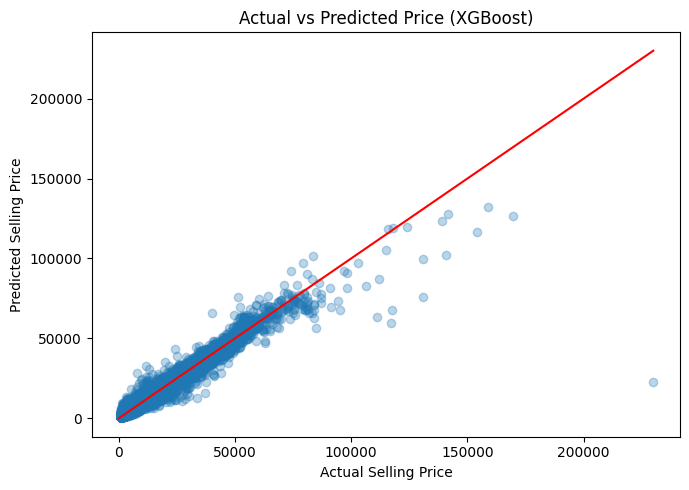

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(results["actual_price"], results["pred_price"], alpha=0.3)

# Reference diagonal line (perfect predictions)
min_val = min(results["actual_price"].min(), results["pred_price"].min())
max_val = max(results["actual_price"].max(), results["pred_price"].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Price (XGBoost)")
plt.tight_layout()
plt.show()


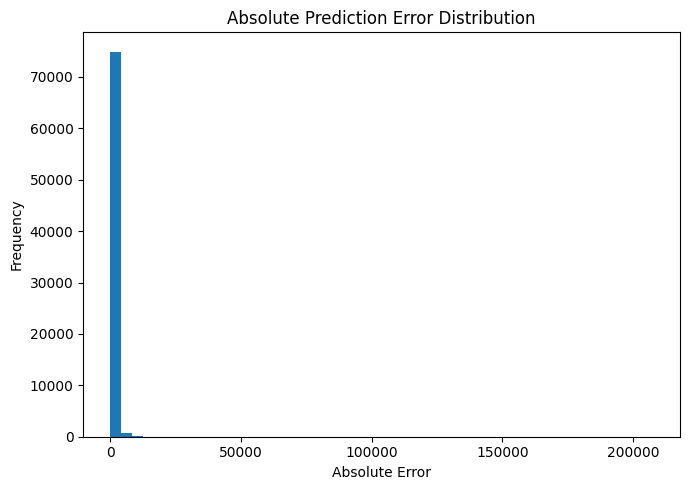

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(results["abs_error"], bins=50)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Absolute Prediction Error Distribution")
plt.tight_layout()
plt.show()


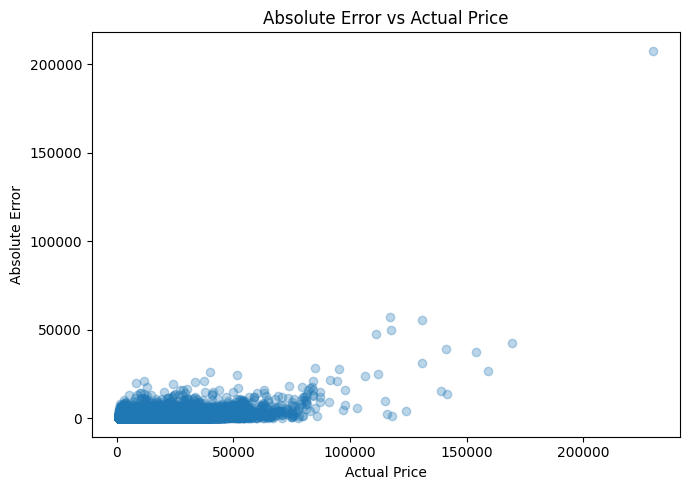

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(results["actual_price"], results["abs_error"], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Actual Price")
plt.tight_layout()
plt.show()


In [ ]:
!pip install shap


In [ ]:
# Checking MAE grouped by seller to see if some high-volume sellers have larger errors.

seller_errors = (
    results
    .groupby("seller")["abs_error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "mae"})
    .sort_values("count", ascending=False)
)

# Keeping only sellers with enough samples.
seller_errors_filtered = seller_errors[seller_errors["count"] >= 1000]
seller_errors_filtered.head(10)


,count,mae
seller,,
ford motor credit company llc,2719,864.443701
nissan-infiniti lt,2572,869.008306
santander consumer,2224,735.851438
avis corporation,1889,385.557630
the hertz corporation,1821,547.392826
wells fargo dealer services,1429,862.809027
nissan infiniti lt,1346,961.398176
enterprise veh exchange/rental,1069,598.898659
tdaf remarketing,1055,968.259619


In [ ]:
# Optional: checking error by brand (make).

make_errors = (
    results
    .groupby("make")["abs_error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "mae"})
    .sort_values("count", ascending=False)
)

make_errors_filtered = make_errors[make_errors["count"] >= 1000]
make_errors_filtered.head(10)


,count,mae
make,,
Ford,13116,863.373194
Chevrolet,8432,809.272762
Nissan,7301,825.135763
Toyota,5346,712.905102
Dodge,4317,784.273114
Honda,4020,652.681728
Hyundai,3013,651.351346
BMW,2824,1238.450278
Kia,2530,568.479509


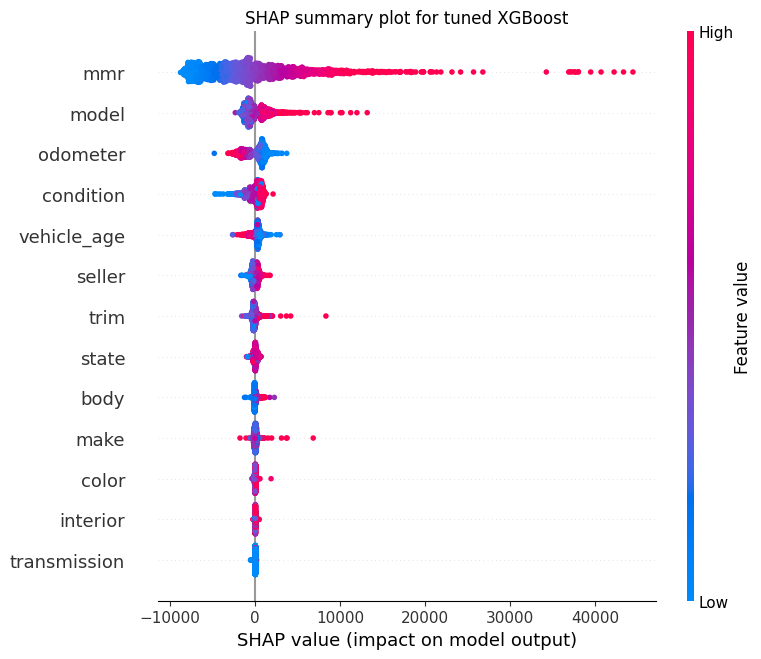

In [ ]:
import shap
import matplotlib.pyplot as plt


# Using a smaller sample for SHAP (full dataset is too slow).
sample_size = 2000
X_shap = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)

# Global SHAP summary plot to show feature importance.
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP summary plot for tuned XGBoost")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
# Saving the trained model + preprocessing objects for Streamlit app.
bundle = {
    "model": best_xgb,     # tuned XGBoost
    "encoder": encoder,
    "scaler": scaler,
    "cat_cols": cat_cols,
    "num_cols": num_cols
}

joblib.dump(bundle, "used_car_model_bundle_final.pkl")
print("Saved model bundle to used_car_model_bundle_final.pkl")


Saved model bundle to used_car_model_bundle_final.pkl


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving used_car_model_bundle.pkl to used_car_model_bundle.pkl


In [ ]:
!pip install category_encoders

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# -----------------------------
# Loading the saved model + preprocessing bundle.
# -----------------------------
BUNDLE_PATH = "used_car_model_bundle_final.pkl"

bundle = joblib.load(BUNDLE_PATH)
model = bundle["model"]
encoder = bundle["encoder"]
scaler = bundle["scaler"]
cat_cols = bundle["cat_cols"]
num_cols = bundle["num_cols"]
feature_order = cat_cols + num_cols

# Deal Score weight settings
W_PRICE, W_MILEAGE, W_AGE = 0.6, 0.2, 0.2

st.set_page_config(page_title="Used Car Price & Deals", layout="wide")

st.title("Used Car Price Prediction & Deal Finder")

st.markdown(
    """
This app uses a tuned XGBoost model trained on historical used-car data.
You can:
- Predict the price of a **single car**, or
- Upload a **CSV of listings** and see the **best deals** ranked by Deal Score.
"""
)

# -----------------------------
# Preprocessing function
# -----------------------------
def preprocess_df(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()

       # Basic string cleanup
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].astype(str).str.lower().str.strip()
# Create vehicle_age if missing
    if "vehicle_age" not in df.columns:
        if "saledate" in df.columns:
            df["saledate"] = pd.to_datetime(df["saledate"], errors="coerce")
            df["sale_year"] = df["saledate"].dt.year
            df["vehicle_age"] = df["sale_year"] - df["year"]
        elif "year" in df.columns:
            df["vehicle_age"] = 2025 - df["year"]

   # Fill any missing expected columns
    missing_cols = [c for c in feature_order if c not in df.columns]
    if missing_cols:
        st.warning(
            f"The following expected columns are missing and will be filled with 0: {missing_cols}"
        )
        for c in missing_cols:
            df[c] = 0

    X = df[feature_order].copy()

    # Encoding and scaling using the trained preprocessing objects
    if cat_cols:
        X[cat_cols] = encoder.transform(X[cat_cols])
    if num_cols:
        X[num_cols] = scaler.transform(X[num_cols])

    return X

# -----------------------------
# Deal Score for uploaded CSV
# -----------------------------
def compute_deal_scores(df_raw: pd.DataFrame, pred_prices: np.ndarray) -> pd.DataFrame:
    """
    df_raw: original listings (should contain sellingprice/price, odometer, year, optionally saledate/vehicle_age)
    pred_prices: predicted fair prices
    """
    results = df_raw.copy()
    results["pred_price"] = pred_prices

       # Ensure vehicle_age exists
    if "vehicle_age" not in results.columns:
        if "saledate" in results.columns:
            results["saledate"] = pd.to_datetime(results["saledate"], errors="coerce")
            results["sale_year"] = results["saledate"].dt.year
            results["vehicle_age"] = results["sale_year"] - results["year"]
        elif "year" in results.columns:
            results["vehicle_age"] = 2025 - results["year"]


    # Choose correct price column
    if "sellingprice" in results.columns:
        results["actual_price"] = results["sellingprice"]
    elif "price" in results.columns:
        results["actual_price"] = results["price"]
    else:
        st.warning("No 'sellingprice' or 'price' column found; Deal Score is not meaningful.")
        return results


    # Price value component
    price_value = (results["pred_price"] - results["actual_price"]) / results["pred_price"]
    results["price_value"] = price_value.clip(-1, 1)

       # Mileage score
    if "odometer" in results.columns:
        odo = results["odometer"].astype(float)
        odo_min, odo_max = 0.0, 200_000.0
        mileage_score = 1 - (odo - odo_min) / (odo_max - odo_min)
        mileage_score = np.clip(mileage_score, 0.0, 1.0)
        results["mileage_score"] = mileage_score
    else:
        results["mileage_score"] = 0.0

      # Age score
    if "vehicle_age" in results.columns:
        age = results["vehicle_age"].astype(float)
    else:
        age = pd.Series(0.0, index=results.index)

    age = age.clip(lower=0, upper=40)
    results["vehicle_age"] = age

    age_min, age_max = 0.0, 40.0
    age_score = 1 - (age - age_min) / (age_max - age_min)
    age_score = np.clip(age_score, 0.0, 1.0)
    results["age_score"] = age_score

    # Final Deal Score
    results["deal_score"] = (
        W_PRICE * results["price_value"]
        + W_MILEAGE * results["mileage_score"]
        + W_AGE * results["age_score"]
    )

    return results

# -----------------------------
# Deal Score for a single car
# -----------------------------
def single_car_deal_score(pred_price: float, listing_price: float,
                          odometer: float, vehicle_age: float):
    # price_value component
    price_value = (pred_price - listing_price) / pred_price if pred_price > 0 else 0.0
    price_value = float(np.clip(price_value, -1, 1))

    # mileage range assumed typical 0–200k
    odo_min, odo_max = 0.0, 200_000.0
    mileage_score = 1 - (odometer - odo_min) / (odo_max - odo_min)
    mileage_score = float(np.clip(mileage_score, 0.0, 1.0))

    # age range clipped 0–40 years
    age_min, age_max = 0.0, 40.0
    age = float(np.clip(vehicle_age, age_min, age_max))
    age_score = 1 - (age - age_min) / (age_max - age_min)
    age_score = float(np.clip(age_score, 0.0, 1.0))

    # weighted combination

    deal_score = (
        W_PRICE * price_value
        + W_MILEAGE * mileage_score
        + W_AGE * age_score
    )


    # Simple interpretation labels
    if deal_score >= 0.25:
        label = "Excellent deal"
    elif deal_score >= 0.10:
        label = "Good deal"
    elif deal_score >= -0.05:
        label = "Fair / borderline"
    else:
        label = "Likely overpriced"

    return deal_score, price_value, mileage_score, age_score, label

# -----------------------------
# Interface Tabs
# -----------------------------
tab1, tab2 = st.tabs(["🔮 Single Car Prediction", "📁 Upload CSV & Find Best Deals"])

# === TAB 1 ===
with tab1:
    st.subheader("Predict price for a single car")

    col1, col2, col3 = st.columns(3)
# Basic car details inputs
    with col1:
        year = st.number_input("Year", min_value=1980, max_value=2025, value=2015)
        odometer = st.number_input("Odometer", min_value=0.0, value=60000.0, step=1000.0)
        condition = st.number_input("Condition (numeric)", min_value=0.0, max_value=5.0, value=3.0, step=0.1)
        mmr = st.number_input("MMR (market reference price)", min_value=0.0, value=10000.0, step=500.0)

    with col2:
        make = st.text_input("Make", value="ford")
        model_name = st.text_input("Model", value="focus")
        trim = st.text_input("Trim", value="se")
        body = st.text_input("Body", value="sedan")
        state = st.text_input("State", value="ca")

    with col3:
        transmission = st.text_input("Transmission", value="automatic")
        color = st.text_input("Exterior colour", value="black")
        interior = st.text_input("Interior", value="black")
        seller = st.text_input("Seller", value="dealer")


    listing_price = st.number_input(
         "Listing / asking price from the advert",
        min_value=0.0, value=0.0, step=500.
    )
 # Predict button
    if st.button("Predict Price and Deal", type="primary"):
        vehicle_age = 2025 - year

        raw = {
            "year": year,
            "odometer": float(odometer),
            "condition": float(condition),
            "mmr": float(mmr),
            "vehicle_age": float(vehicle_age),
            "make": make.lower(),
            "model": model_name.lower(),
            "trim": trim.lower(),
            "body": body.lower(),
            "state": state.lower(),
            "transmission": transmission.lower(),
            "color": color.lower(),
            "interior": interior.lower(),
            "seller": seller.lower()
        }

        single_df = pd.DataFrame([raw])
        X_processed = preprocess_df(single_df)
        pred_price = model.predict(X_processed)[0]

        st.success(f"Predicted selling price: **${pred_price:,.0f}**")

        if listing_price > 0:
            deal_score, pv, ms, ascore, label = single_car_deal_score(
                pred_price=pred_price,
                listing_price=listing_price,
                odometer=odometer,
                vehicle_age=vehicle_age
            )

            st.write(f"**Deal Score:** {deal_score:.4f}")
            st.write(
                f"- Price value component: {pv:.4f}  \n"
                f"- Mileage score: {ms:.4f}  \n"
                f"- Age score: {ascore:.4f}"
            )
            st.info(f"Overall this looks like: **{label}**")
        else:
            st.info("Enter a listing price above to see a Deal Score.")


# === TAB 2 ===

with tab2:
    st.subheader("Upload a CSV of listings to find the best deals")

    st.markdown(
        """
**Recommended columns** in your CSV:
- `year`, `odometer`, `sellingprice` (or `price`)
- plus as many as possible of:
  `make`, `model`, `trim`, `body`, `transmission`, `color`, `interior`, `seller`, `state`, `mmr`, `vehicle_age`, `saledate`
"""
    )

    uploaded_csv = st.file_uploader("Choose a CSV file of listings", type=["csv"])

    if uploaded_csv is not None:
        df_uploaded = pd.read_csv(uploaded_csv)
        st.write("Preview of uploaded data:")
        st.dataframe(df_uploaded.head())

        X_upload = preprocess_df(df_uploaded)
        preds_upload = model.predict(X_upload)

        results_upload = compute_deal_scores(df_uploaded, preds_upload)

        k = st.slider("Number of top deals to show", min_value=5, max_value=50, value=10, step=5)

        cols_to_show = [
            "actual_price", "pred_price", "price_value",
            "mileage_score", "age_score", "deal_score",
            "year", "vehicle_age", "odometer",
            "make", "model", "trim", "body", "state", "seller"
        ]
        cols_to_show = [c for c in cols_to_show if c in results_upload.columns]

        st.markdown("### Top deals by Deal Score")


        topk = results_upload.sort_values("deal_score", ascending=False).head(k)[cols_to_show].copy()

         # Rounding for cleaner display
        for col in ["price_value", "mileage_score", "age_score", "deal_score"]:
            if col in topk.columns:
                topk[col] = topk[col].round(4)

        st.dataframe(topk)

        st.caption(
            "Deal Score combines price difference, mileage and age. "
            "Higher scores indicate better value-for-money according to the model."
        )
    else:
        st.info("Upload a CSV file to see ranked deals.")


Overwriting app.py


In [ ]:
# Installing required packages
!pip install streamlit pyngrok category_encoders joblib xgboost scikit-learn --quiet

# Adding ngrok auth token to enable public URL for the Streamlit app
!ngrok config add-authtoken AUTHENTICATIONTOKEN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.7 MB/s eta 0:00:00
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
import threading, time, os

# Function to launch the Streamlit app on a specific port
def run_app():
    os.system("streamlit run app.py --server.port 8501")
# Running the Streamlit app in a separate thread so Colab doesn't block
thread = threading.Thread(target=run_app)
thread.start()

# Giving the app a few seconds to start
time.sleep(8)
# Creating a public URL through ngrok
public_url = ngrok.connect(8501)
print(" Streamlit app is live here:")
print(public_url.public_url)


✅ Streamlit app is live here:
https://sinistrous-macrographic-laurette.ngrok-free.dev
